# Task 2: Team Possession and Goal Scoring - Avaya Manandhar

## Analytic question

Did teams with higher average possession score more goals per match than teams with lower average possession in the FIFA World Cup 2026?

## Objective and hypotheses

This analysis investigates whether average team possession was associated with goal scoring during the FIFA World Cup 2026.

The outcome variable is goals scored per match. This was selected instead of total goals because teams played different numbers of matches.

Teams are classified into high-possession and low-possession groups using the median possession percentage of all teams.

Null hypothesis, \(H_0\): There is no difference in mean goals per match between high-possession and low-possession teams.

Alternative hypothesis, \(H_1\): There is a difference in mean goals per match between high-possession and low-possession teams.

The significance level for the hypothesis test is \(\alpha = 0.05\).

## Data source

The dataset used in this analysis was obtained from the FBref Squad Standard Stats table for the 2026 World Cup.

Source: FBref  
Table: Squad Standard Stats, 2026 World Cup  
URL: https://fbref.com/en/comps/1/stats/World-Cup-Stats  
Date accessed: 9 September 2026

The table contains one record per national team and includes team-level statistics such as possession, matches played, goals, assists, cards, and playing time.

The variables selected for this analysis were:

- `Squad`: national team name
- `Poss`: average possession percentage
- `MP`: matches played
- `Gls`: total goals scored

The complete table was retained as the raw dataset. Python was then used to select and prepare the variables required for this analysis.

In [1]:
# Import libraries for data processing, visualisation, and statistical analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Improve the readability of charts used in the presentation.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [20]:
# Load the complete FBref table.
# The first row contains grouped headings, so it is skipped.
raw_df = pd.read_csv(
    "data/raw_fbref_team_stats.csv",
    skiprows=1
)

# Display the dataset size and column names before data wrangling.
print("Raw dataset dimensions:", raw_df.shape)
print("\nRaw dataset column names:")
print(raw_df.columns.tolist())

# Display the first five records from the original dataset.
raw_df.head()

Raw dataset dimensions: (48, 21)

Raw dataset column names:
['Squad', '# Pl', 'Age', 'Poss', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK']


,Squad,# Pl,Age,Poss,MP,Starts,Min,90s,Gls,Ast,...,G-PK,PK,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK
0,dz Algeria,22,27.3,61.0,4,44,360,4.0,5,3,...,5,0,0,3,0,1.25,0.75,2.00,1.25,2.00
1,ar Argentina,24,29.6,57.6,8,88,810,9.0,18,12,...,17,1,3,15,1,2.00,1.33,3.33,1.89,3.22
2,au Australia,23,25.3,41.0,4,44,390,4.3,2,1,...,2,0,0,5,0,0.46,0.23,0.69,0.46,0.69
3,at Austria,20,28.8,45.0,4,44,360,4.0,5,4,...,4,1,1,5,0,1.25,1.00,2.25,1.00,2.00
4,be Belgium,23,29.2,51.2,6,66,570,6.3,13,10,...,12,1,1,6,1,2.05,1.58,3.63,1.89,3.47


## Data wrangling and validation

The raw table was retained unchanged as evidence of the original data source. A separate analysis dataset was created by selecting only variables relevant to the analytic question.

The team name field included two-letter country codes. These codes were removed to improve readability. The selected data was then checked for missing values, duplicate teams, and invalid values before analysis.

In [4]:
# Select variables directly relevant to possession and goal-scoring analysis.
df = raw_df[["Squad", "Poss", "MP", "Gls"]].copy()

# Rename variables to clear, analysis-friendly names.
df = df.rename(columns={
    "Squad": "team",
    "Poss": "possession",
    "MP": "matches_played",
    "Gls": "goals"
})

# Remove the two-letter country code at the beginning of team names.
# For example, "au Australia" becomes "Australia".
df["team"] = df["team"].str.replace(r"^[a-z]{2}\s+", "", regex=True)

# Convert numeric variables to numeric data types.
# Any invalid values would become missing values and be identified in validation.
df["possession"] = pd.to_numeric(df["possession"], errors="coerce")
df["matches_played"] = pd.to_numeric(df["matches_played"], errors="coerce")
df["goals"] = pd.to_numeric(df["goals"], errors="coerce")

df.head()

,team,possession,matches_played,goals
0,Algeria,61.0,4,5
1,Argentina,57.6,8,18
2,Australia,41.0,4,2
3,Austria,45.0,4,5
4,Belgium,51.2,6,13


In [5]:
# Check for missing values in all selected variables.
print("Missing values by variable:")
print(df.isna().sum())

# Check whether any team appears more than once.
print("\nDuplicate team names:", df["team"].duplicated().sum())

# Check basic data ranges to identify invalid values.
print("\nData ranges:")
print("Possession:", df["possession"].min(), "to", df["possession"].max())
print("Matches played:", df["matches_played"].min(), "to", df["matches_played"].max())
print("Goals:", df["goals"].min(), "to", df["goals"].max())

# Remove any records missing key variables and exclude teams with no matches.
df = df.dropna(subset=["team", "possession", "matches_played", "goals"])
df = df[df["matches_played"] > 0].copy()

print("\nFinal number of valid team records:", len(df))

Missing values by variable:
team              0
possession        0
matches_played    0
goals             0
dtype: int64

Duplicate team names: 0

Data ranges:
Possession: 30.0 to 66.3
Matches played: 3 to 8
Goals: 0 to 20

Final number of valid team records: 48


## Data preparation and sampling

The raw FBref table contained 48 national team records and 21 variables. Python was used to select the four variables required for this analysis: team name, possession, matches played, and total goals.

The two-letter country codes included in the team names were removed. The selected columns were converted to numeric format, and the data was checked for missing values, duplicate teams, and invalid values.

No missing values or duplicate team names were identified. All 48 teams had played at least one match and were retained for the analysis.

A new variable called `goals_per_match` was calculated by dividing each team's total goals by its number of matches played. This standardised goal production because teams played different numbers of matches.

The median possession value was used to divide the teams into two groups. Teams above the median were classified as high possession, while teams at or below the median were classified as low possession. This produced two approximately balanced groups for comparison.

In [7]:
# Calculate goals per match to account for differences in matches played.
df["goals_per_match"] = df["goals"] / df["matches_played"]

# Use the median possession value as the threshold for group classification.
median_possession = df["possession"].median()

# Classify teams above the median as high possession.
# Teams at or below the median are classified as low possession.
df["possession_group"] = np.where(
    df["possession"] > median_possession,
    "High possession",
    "Low possession"
)

# Retain only variables required for later analysis.
analysis_df = df[
    [
        "team",
        "matches_played",
        "goals",
        "possession",
        "goals_per_match",
        "possession_group"
    ]
].copy()

# Display the grouping threshold and number of teams in each group.
print(f"Median possession threshold: {median_possession:.2f}%")
print("\nTeams in each possession group:")
print(analysis_df["possession_group"].value_counts())

analysis_df.head(5)

Median possession threshold: 49.80%

Teams in each possession group:
possession_group
Low possession     25
High possession    23
Name: count, dtype: int64


,team,matches_played,goals,possession,goals_per_match,possession_group
0,Algeria,4,5,61.0,1.250000,High possession
1,Argentina,8,18,57.6,2.250000,High possession
2,Australia,4,2,41.0,0.500000,Low possession
3,Austria,4,5,45.0,1.250000,Low possession
4,Belgium,6,13,51.2,2.166667,High possession


In [19]:
# Save the prepared dataset separately from the original raw data.
analysis_df.to_csv(
    "data/teams_possession_goals_cleaned.csv",
    index=False
)

print("Prepared dataset saved successfully.")
print("File created: data/teams_possession_goals_cleaned.csv")

Prepared dataset saved successfully.
File created: data/teams_possession_goals_cleaned.csv


## Descriptive statistics

Descriptive statistics are used to summarise goals per match for high-possession and low-possession teams. The mean shows the average scoring rate, the median provides the middle value, and the standard deviation shows how much scoring rates vary between teams.

In [9]:
# Separate goals-per-match observations by possession group.
high_possession = analysis_df.loc[
    analysis_df["possession_group"] == "High possession",
    "goals_per_match"
]

low_possession = analysis_df.loc[
    analysis_df["possession_group"] == "Low possession",
    "goals_per_match"
]

# Produce a descriptive-statistics table for both groups.
descriptive_stats = analysis_df.groupby("possession_group")[
    "goals_per_match"
].agg(
    count="count",
    mean="mean",
    median="median",
    std_dev="std",
    minimum="min",
    maximum="max"
).round(3)

descriptive_stats

,count,mean,median,std_dev,minimum,maximum
possession_group,,,,,,
High possession,23,1.737,1.667,0.630,0.5,2.75
Low possession,25,0.831,0.667,0.499,0.0,2.00


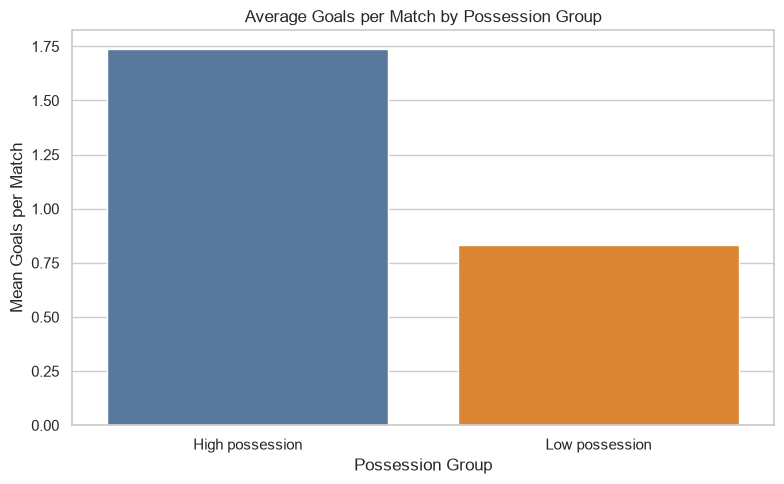

In [10]:
# Compare the average goals per match visually between possession groups.
group_means = analysis_df.groupby("possession_group", as_index=False)[
    "goals_per_match"
].mean()

sns.barplot(
    data=group_means,
    x="possession_group",
    y="goals_per_match",
    hue="possession_group",
    legend=False,
    palette=["#4C78A8", "#F58518"]
)

plt.title("Average Goals per Match by Possession Group")
plt.xlabel("Possession Group")
plt.ylabel("Mean Goals per Match")
plt.tight_layout()
plt.show()

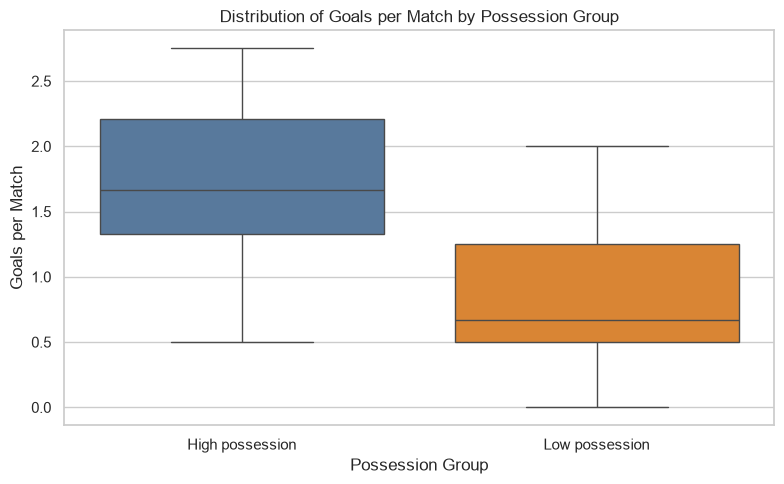

In [11]:
# Show the distribution, spread, and possible outliers in each group.
sns.boxplot(
    data=analysis_df,
    x="possession_group",
    y="goals_per_match",
    hue="possession_group",
    legend=False,
    palette=["#4C78A8", "#F58518"]
)

plt.title("Distribution of Goals per Match by Possession Group")
plt.xlabel("Possession Group")
plt.ylabel("Goals per Match")
plt.tight_layout()
plt.show()

## Confidence interval

A 95% confidence interval was calculated for the mean goals per match of high-possession teams. The interval estimates a plausible range for the population mean scoring rate of teams classified as high possession.

In [12]:
# Calculate a 95% confidence interval for the high-possession group mean.
n_high = len(high_possession)
mean_high = high_possession.mean()
std_high = high_possession.std(ddof=1)
standard_error_high = std_high / np.sqrt(n_high)

# The t-distribution is used because the population standard deviation is unknown.
t_critical = stats.t.ppf(0.975, df=n_high - 1)
margin_of_error = t_critical * standard_error_high

ci_lower = mean_high - margin_of_error
ci_upper = mean_high + margin_of_error

print(f"High-possession teams: n = {n_high}")
print(f"Mean goals per match: {mean_high:.3f}")
print(f"95% confidence interval: ({ci_lower:.3f}, {ci_upper:.3f})")

High-possession teams: n = 23
Mean goals per match: 1.737
95% confidence interval: (1.464, 2.009)


## Statistical assumptions

The two-sample t-test assumes that observations are independent, the outcome variable is approximately normally distributed within each group, and the two groups have comparable variance when using the equal-variance version of the test.

Each team is treated as one independent observation. Because each group contains a relatively small number of teams, visual inspection and a Shapiro-Wilk normality test are used to assess the distribution of goals per match. Levene's test is used to examine variance equality.

The results should be interpreted carefully because this is tournament-level observational data. The analysis identifies an association between possession and goal scoring, not proof that possession causes more goals.

In [13]:
# Assess normality using the Shapiro-Wilk test.
# A p-value greater than 0.05 suggests no strong evidence against normality.
shapiro_high_stat, shapiro_high_p = stats.shapiro(high_possession)
shapiro_low_stat, shapiro_low_p = stats.shapiro(low_possession)

print("Shapiro-Wilk normality test")
print(f"High possession: statistic = {shapiro_high_stat:.3f}, p-value = {shapiro_high_p:.3f}")
print(f"Low possession: statistic = {shapiro_low_stat:.3f}, p-value = {shapiro_low_p:.3f}")

# Assess whether the two groups have equal variances.
# A p-value greater than 0.05 suggests no strong evidence of unequal variance.
levene_stat, levene_p = stats.levene(high_possession, low_possession)

print("\nLevene's variance-equality test")
print(f"Statistic = {levene_stat:.3f}, p-value = {levene_p:.3f}")

Shapiro-Wilk normality test
High possession: statistic = 0.959, p-value = 0.450
Low possession: statistic = 0.943, p-value = 0.171

Levene's variance-equality test
Statistic = 1.198, p-value = 0.279


## Assumption test results

The Shapiro-Wilk normality test produced p-values of 0.450 for high-possession teams and 0.171 for low-possession teams. Both p-values are greater than 0.05, so there was no statistically significant evidence that either group was non-normal.

Levene's test produced a p-value of 0.279, which is greater than 0.05. Therefore, there was no statistically significant evidence that the variance of goals per match was different between the two groups.

Welch's two-sample t-test was used because it is appropriate when group sizes are different and does not require the assumption of equal variances.

In [15]:
# Using Welch's independent two-sample t-test.
# Welch's test does not require equal group variances and is more robust
# when group sizes or variances differ.
t_statistic, p_value = stats.ttest_ind(
    high_possession,
    low_possession,
    equal_var=False
)

mean_difference = mean_high - low_possession.mean()

print("Welch's two-sample t-test")
print(f"Mean difference, high minus low: {mean_difference:.3f} goals per match")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nDecision: Reject the null hypothesis.")
    print("There is evidence of a statistically significant difference in mean goals per match.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a statistically significant difference in mean goals per match.")

Welch's two-sample t-test
Mean difference, high minus low: 0.906 goals per match
t-statistic: 5.493
p-value: 0.0000

Decision: Reject the null hypothesis.
There is evidence of a statistically significant difference in mean goals per match.


## Results and interpretation

High-possession teams scored an average of **1.737 goals per match**, compared with **0.831 goals per match** for low-possession teams.

The difference between the two group means was **0.906 goals per match**. Therefore, high-possession teams scored approximately 0.91 more goals per match on average.

The 95% confidence interval for the mean goals per match of high-possession teams was **(1.464, 2.009)**.

The Welch two-sample t-test produced a test statistic of **5.493** and a p-value of **less than 0.001**. Since the p-value was below the 0.05 significance level, the null hypothesis was rejected.

The analysis provides statistically significant evidence that high-possession teams scored more goals per match than low-possession teams in the FIFA World Cup 2026 dataset.

This result shows an association rather than causation. Factors such as team quality, opponent strength, shot quality, tactics, match stage, and tournament progression may also affect goal scoring.

## Limitations

- The analysis includes only 48 teams from one World Cup tournament, so the findings may not apply to other tournaments or football competitions.
- Teams were divided into high-possession and low-possession groups using the median possession value. This simplifies a continuous measure and may hide smaller differences between teams close to the median.
- Possession percentage measures how long a team had the ball, but it does not measure the quality of passing, chances created, or shot quality.
- The analysis does not control for factors such as team strength, opponent strength, tactical approach, match stage, red cards, or tournament progression.
- The results show an association between possession and goals per match. They do not prove that possession caused teams to score more goals.

## Conclusion

The high-possession group had a higher average goals-per-match value than the low-possession group. The difference was 0.906 goals per match.

The Welch two-sample t-test found this difference to be statistically significant, with a p-value below 0.001. Therefore, within this FIFA World Cup 2026 dataset, higher possession was associated with higher goal scoring.

This result should not be generalised to all football matches because the analysis covered one tournament and did not control for other factors that influence goals.